## Data Preprocessing

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
df=pd.read_csv("Ridge_Regression_HousingData.csv")

In [31]:
df

,Unnamed: 0,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Median House Value
0,0,3.9816,27.0,4.928668,1.122476,3009.0,4.049798,33.73,-117.93,1.795
1,1,3.4531,23.0,4.021339,1.099338,2511.0,1.847682,34.14,-118.13,2.109
2,2,6.3942,4.0,5.681272,1.095774,5613.0,2.176425,37.78,-121.95,3.567
3,3,2.2243,32.0,5.685221,1.009597,1542.0,2.959693,38.69,-121.45,0.892
4,4,3.0217,9.0,5.006324,1.071146,3265.0,2.581028,37.69,-121.04,1.609
...,...,...,...,...,...,...,...,...,...,...
16507,16507,5.7214,16.0,6.231429,0.917143,1133.0,3.237143,34.12,-117.68,2.594
16508,16508,2.7254,41.0,3.834829,0.985637,986.0,1.770197,34.02,-118.47,4.444
16509,16509,2.5288,16.0,5.315638,1.060258,2463.0,3.533716,36.98,-120.05,0.618
16510,16510,2.6165,34.0,4.593168,1.031056,1166.0,3.621118,33.89,-118.24,1.009


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          16512 non-null  int64  
 1   MedInc              16512 non-null  float64
 2   HouseAge            16512 non-null  float64
 3   AveRooms            16512 non-null  float64
 4   AveBedrms           16512 non-null  float64
 5   Population          16512 non-null  float64
 6   AveOccup            16512 non-null  float64
 7   Latitude            16512 non-null  float64
 8   Longitude           16512 non-null  float64
 9   Median House Value  16512 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 1.3 MB


In [33]:
df.describe()

,Unnamed: 0,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Median House Value
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,8255.500000,3.859050,28.592902,5.429562,1.096896,1429.927689,3.055425,35.632512,-119.565484,2.062298
std,4766.748158,1.887126,12.615380,2.552593,0.494423,1149.664255,10.780690,2.133356,1.998334,1.151592
min,0.000000,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,4127.750000,2.562500,18.000000,4.439906,1.006131,785.000000,2.430205,33.930000,-121.790000,1.189000
50%,8255.500000,3.531300,29.000000,5.227757,1.048689,1168.000000,2.814815,34.260000,-118.500000,1.786000
75%,12383.250000,4.725000,37.000000,6.051724,1.099955,1729.000000,3.278159,37.710000,-118.007500,2.646000
max,16511.000000,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.490000,5.000010


In [34]:
df.dtypes

Unnamed: 0              int64
MedInc                float64
HouseAge              float64
AveRooms              float64
AveBedrms             float64
Population            float64
AveOccup              float64
Latitude              float64
Longitude             float64
Median House Value    float64
dtype: object

In [35]:
df.shape

(16512, 10)

In [36]:
df.isnull().sum()

Unnamed: 0            0
MedInc                0
HouseAge              0
AveRooms              0
AveBedrms             0
Population            0
AveOccup              0
Latitude              0
Longitude             0
Median House Value    0
dtype: int64

In [37]:
df.duplicated().sum()

np.int64(0)

## EDA

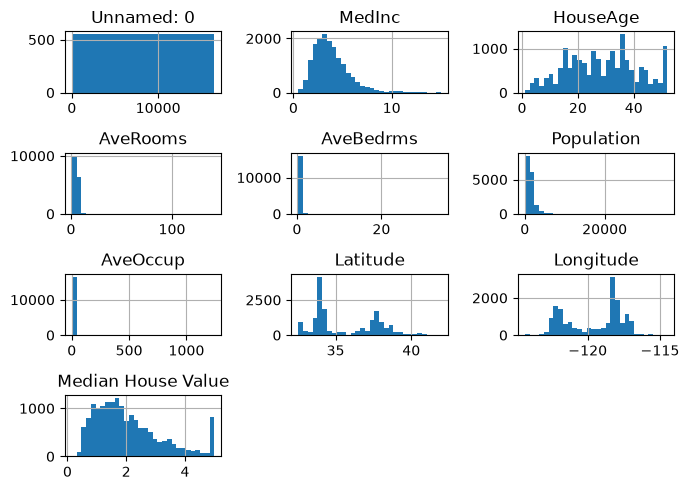

In [38]:
df.hist(figsize=(7,5),bins=30)
plt.tight_layout()
plt.show()

# Model Training

#### LINEAR REGRESSION

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error,mean_absolute_percentage_error,r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
df.columns

Index(['Unnamed: 0', 'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
       'Population', 'AveOccup', 'Latitude', 'Longitude',
       'Median House Value'],
      dtype='str')

In [40]:
X=df.drop('Median House Value',axis=1)
y=df['Median House Value']

In [41]:
X.shape

(16512, 9)

In [42]:
y.shape

(16512,)

In [43]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LinearRegression()

model.fit(X_train,y_train)

y_pred=model.predict(X_test)

L_MSE=mean_squared_error(y_test,y_pred)
L_MAE=mean_absolute_error(y_test,y_pred)
L_R2=r2_score(y_test,y_pred)

print()
print("MSE:      ",L_MSE)
print("MAE:      ",L_MAE)
print("R2_score: ",L_R2)


MSE:       0.5502325645780866
MAE:       0.5432964681987706
R2_score:  0.5893053856582937


### Polynomial regression

In [44]:
poly=PolynomialFeatures(degree=2)

x_train_poly=poly.fit_transform(X_train)
x_test_poly=poly.transform(X_test)

scaler=StandardScaler()
x_train_scaled=poly.fit_transform(x_train_poly)
x_test_scaled=poly.fit_transform(x_test_poly)

model=LinearRegression()

model=model.fit(x_train_scaled,y_train)

y_pred=model.predict(x_test_scaled)

P_MSE=mean_squared_error(y_test,y_pred)
P_MAE=mean_absolute_error(y_test,y_pred)
P_R2=r2_score(y_test,y_pred)

print()
print("MSE:      ",P_MSE)
print("MAE:      ",P_MAE)
print("R2_score: ",P_R2)


MSE:       3.486343043753945
MAE:       0.7929420135962614
R2_score:  -1.6022129622868198


### Ridge Regression

In [45]:
from sklearn.linear_model import Ridge
scalar=StandardScaler()

X_train_scaled=scalar.fit_transform(X_train)
X_test_scaled=scalar.transform(X_test)

ridge=Ridge(alpha=1.0)

ridge.fit(X_train_scaled,y_train)

y_pred=ridge.predict(X_test_scaled)

R_MSE=mean_squared_error(y_test,y_pred)
R_MAE=mean_absolute_error(y_test,y_pred)
R_R2=r2_score(y_test,y_pred)

print()
print("MSE:      ",R_MSE)
print("MAE:      ",R_MAE)
print("R2_score: ",R_R2)



MSE:       0.5502485329281543
MAE:       0.5432858445096191
R2_score:  0.5892934668519655


### Lasso Regression

In [46]:
from sklearn.linear_model import Lasso

lasso=Lasso(alpha=0.1,max_iter=10000)

lasso.fit(X_train,y_train)

y_pred=lasso.predict(X_test_scaled)

MSE=mean_squared_error(y_test,y_pred)
MAE=mean_absolute_error(y_test,y_pred)
R2=r2_score(y_test,y_pred)

print()
print("MSE:      ",MSE)
print("MAE:      ",MAE)
print("R2_score: ",R2)



MSE:       97.37891103192959
MAE:       9.825282515962169
R2_score:  -71.68380115222718


c:\Users\vaish\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
